# Trabajo Final

**Nombre:** Alexis Mauricio Garzón Pardo

**Link:** https://datosabiertos.gob.ec/dataset/personas-desaparecidas/resource/a9364f2d-079f-4a11-9808-d8ba9eea8ed1



In [1]:
# Importamos las librerias

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3
from sqlalchemy import create_engine
import json

In [2]:
import pandas as pd

# Leer la hoja 1, saltando la primera fila y solo tomando columnas desde la B en adelante
data_path = "mdi_personas_desaparecidas_pm_historico_2014_2024.xlsx"

# Cargar Excel, saltando la fila 0
df = pd.read_excel(data_path, sheet_name=1, engine='openpyxl', skiprows=1)

# Eliminar la primera columna si está vacía o con espacios
if df.columns[0] == df.columns[0] or df.columns[0].strip() == "":
    df = df.iloc[:, 1:]

# Resetear índice
df = df.reset_index(drop=True)

# Revisar el resultado
print("Archivo cargado:", data_path)
print("Dimensiones:", df.shape)
df.head()

Archivo cargado: mdi_personas_desaparecidas_pm_historico_2014_2024.xlsx
Dimensiones: (68072, 20)


,zona,provincia,canton,distrito,circuito,subcircuito,sexo,nacionalidad,edad_aproximada,rango_edad,etnia,fecha_localizacion,motivo_desaparicion,motivo_desaparicion_observada,situacion_actual,dias_solucion,latitud_desaparicion,longitud_desaparicion,fecha_denuncia,fecha_desaparicion
0,ZONA 2,PICHINCHA,QUITO,EUGENIO ESPEJO,SAN ISIDRO DEL INCA,SAN ISIDRO DEL INCA 4,MUJER,COLOMBIA,14,ADOLESCENTES,MESTIZO/A,2018-01-24 00:00:00,CAUSAS FAMILIARES,PROBLEMAS SENTIMENTALES,ENCONTRADO,44,'-0.151062400000000013,'-78.4581433999999831,2017-12-11,2017-12-07
1,ZONA 5,GUAYAS,GUAYAQUIL,FLORIDA,MARTHA DE ROLDOS,MARTHA DE ROLDOS 1,HOMBRE,ECUADOR,20,ADULTOS,MESTIZO/A,2021-06-09 00:00:00,CAUSAS SOCIALES,DROGADICCION,ENCONTRADO,9,'-2.15486900000000015,'-79.9185705999999954,2021-05-31,2021-05-24
2,ZONA 3,TUNGURAHUA,AMBATO,AMBATO SUR,LETAMENDI,LETAMENDI 1,MUJER,ECUADOR,17,ADOLESCENTES,MESTIZO/A,2021-06-02 00:00:00,CAUSAS FAMILIARES,NO RELACIONADOS A VIOLENCIA,ENCONTRADO,1,'-1.24724970000000002,'-78.6200128999999919,2021-06-01,2021-06-01
3,ZONA 3,COTOPAXI,LATACUNGA,LATACUNGA,JOSEGUANGO,JOSEGUANGO 1,HOMBRE,ECUADOR,14,ADOLESCENTES,INDIGENA,2021-05-31 00:00:00,CAUSAS FAMILIARES,PROBLEMAS SENTIMENTALES,ENCONTRADO,2,'-0.865133903604262899,'-78.5948506211418589,2021-05-29,2021-05-28
4,ZONA 1,SUCUMBIOS,GONZALO PIZARRO,SUCUMBIOS,LUMBAQUI,LUMBAQUI 1,MUJER,COLOMBIA,17,ADOLESCENTES,MESTIZO/A,2019-07-06 00:00:00,CAUSAS FAMILIARES,PROBLEMAS SENTIMENTALES,ENCONTRADO,3,'0.046658100000000001,'-77.3281349999999748,2019-07-03,2019-07-01


In [3]:
#  Inspección básica
df.info()
display(df.describe(include='all').T)
print("\nNulos por columna:\n", df.isna().sum())

# Mostrar todas las filas duplicadas
duplicadas = df[df.duplicated()]

print("Filas duplicadas encontradas:")
print(duplicadas)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68072 entries, 0 to 68071
Data columns (total 20 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   zona                           68072 non-null  object        
 1   provincia                      68072 non-null  object        
 2   canton                         68072 non-null  object        
 3   distrito                       68072 non-null  object        
 4   circuito                       68072 non-null  object        
 5   subcircuito                    68072 non-null  object        
 6   sexo                           68072 non-null  object        
 7   nacionalidad                   67834 non-null  object        
 8   edad_aproximada                68072 non-null  object        
 9   rango_edad                     68072 non-null  object        
 10  etnia                          68072 non-null  object        
 11  fecha_localizac

,count,unique,top,freq,mean,min,25%,50%,75%,max
zona,68072,8,ZONA 5,20304,NaN,NaN,NaN,NaN,NaN,NaN
provincia,68072,24,PICHINCHA,16712,NaN,NaN,NaN,NaN,NaN,NaN
canton,68072,221,QUITO,15129,NaN,NaN,NaN,NaN,NaN,NaN
distrito,68072,141,ELOY ALFARO,3004,NaN,NaN,NaN,NaN,NaN,NaN
circuito,68072,969,CENTRO,861,NaN,NaN,NaN,NaN,NaN,NaN
subcircuito,68072,1650,TERMINAL TERRESTRE 1,421,NaN,NaN,NaN,NaN,NaN,NaN
sexo,68072,2,MUJER,43090,NaN,NaN,NaN,NaN,NaN,NaN
nacionalidad,67834,36,ECUADOR,65749,NaN,NaN,NaN,NaN,NaN,NaN
edad_aproximada,68072.0,103.0,15.0,8426.0,NaN,NaN,NaN,NaN,NaN,NaN
rango_edad,68072,4,ADOLESCENTES,34495,NaN,NaN,NaN,NaN,NaN,NaN



Nulos por columna:
 zona                               0
provincia                          0
canton                             0
distrito                           0
circuito                           0
subcircuito                        0
sexo                               0
nacionalidad                     238
edad_aproximada                    0
rango_edad                         0
etnia                              0
fecha_localizacion                 0
motivo_desaparicion                0
motivo_desaparicion_observada      0
situacion_actual                   0
dias_solucion                      0
latitud_desaparicion               0
longitud_desaparicion              0
fecha_denuncia                     0
fecha_desaparicion                 0
dtype: int64
Filas duplicadas encontradas:
         zona  provincia     canton            distrito          circuito  \
22     ZONA 5     GUAYAS  GUAYAQUIL             FLORIDA  MARTHA DE ROLDOS   
23     ZONA 5     GUAYAS  GUAYAQUIL       

In [59]:
# Copia para trabajar y evitar modificar el original en memoria
df_clean = df.copy()

# Normalizar nombres de columnas 
df_clean.columns = [c.strip() for c in df_clean.columns]

# Convertir InvoiceDate a datetime (convertir fechas)
df_clean['fecha_denuncia'] = pd.to_datetime(df_clean['fecha_denuncia'], errors='coerce')
df_clean['fecha_desaparicion'] = pd.to_datetime(df_clean['fecha_desaparicion'], errors='coerce')

# Rellenar con un valor a las nacionalidades desconocidas y corregir la nacionalidad
df_clean['nacionalidad'] = (
    df_clean['nacionalidad']
    .fillna('DESCONOCIDO')
    .replace('NO_DETERMINADO', 'DESCONOCIDO')
)

# Rellenar con un valor a los motivos desconocidos 
df_clean['motivo_desaparicion'] = (
    df_clean['motivo_desaparicion']
    .replace('SIN_DATO', 'DESCONOCIDO')
)

# Rellenar con un valor a las etnias desconocidas 
df_clean['etnia'] = (
    df_clean['etnia']
    .replace('NO_DETERMINADO', 'DESCONOCIDO')
)

# Eliminar duplicados exactos (misma fila)
before = df_clean.shape[0]
df_clean = df_clean.drop_duplicates()
after = df_clean.shape[0]
print(f"Duplicados eliminados: {before - after}")

# Reset índice final
df_clean = df_clean.reset_index(drop=True)
print("Dimensiones después de limpieza:", df_clean.shape)

Duplicados eliminados: 143
Dimensiones después de limpieza: (67929, 20)


In [60]:
print("\nNulos por columna:\n", df_clean.isna().sum())


Nulos por columna:
 zona                             0
provincia                        0
canton                           0
distrito                         0
circuito                         0
subcircuito                      0
sexo                             0
nacionalidad                     0
edad_aproximada                  0
rango_edad                       0
etnia                            0
fecha_localizacion               0
motivo_desaparicion              0
motivo_desaparicion_observada    0
situacion_actual                 0
dias_solucion                    0
latitud_desaparicion             0
longitud_desaparicion            0
fecha_denuncia                   0
fecha_desaparicion               0
dtype: int64


In [61]:
#  Guardar DataFrame limpio en SQLite
db_filename = "mdi_personas_desaparecidas_pm_historico_2014_2024.db"
engine = create_engine(f"sqlite:///{db_filename}", echo=False)

# Guardar tabla 'mdi_personas_desaparecidas_pm_historico_2014_2024'
df_clean.to_sql("mdi_personas_desaparecidas_pm_historico_2014_2024", con=engine, if_exists='replace', index=False)
print(f"Guardado en SQLite: {db_filename} -> tabla 'mdi_personas_desaparecidas_pm_historico_2014_2024' con {df_clean.shape[0]} filas")

Guardado en SQLite: mdi_personas_desaparecidas_pm_historico_2014_2024.db -> tabla 'mdi_personas_desaparecidas_pm_historico_2014_2024' con 67929 filas


In [62]:
#  Leer datos desde SQLite para verificar
with engine.connect() as conn:
    df_sql = pd.read_sql_table("mdi_personas_desaparecidas_pm_historico_2014_2024", conn)

print("Dimensiones leídas desde SQLite:", df_sql.shape)
df_sql.head()

Dimensiones leídas desde SQLite: (67929, 20)


,zona,provincia,canton,distrito,circuito,subcircuito,sexo,nacionalidad,edad_aproximada,rango_edad,etnia,fecha_localizacion,motivo_desaparicion,motivo_desaparicion_observada,situacion_actual,dias_solucion,latitud_desaparicion,longitud_desaparicion,fecha_denuncia,fecha_desaparicion
0,ZONA 2,PICHINCHA,QUITO,EUGENIO ESPEJO,SAN ISIDRO DEL INCA,SAN ISIDRO DEL INCA 4,MUJER,COLOMBIA,14,ADOLESCENTES,MESTIZO/A,2018-01-24 00:00:00,CAUSAS FAMILIARES,PROBLEMAS SENTIMENTALES,ENCONTRADO,44,'-0.151062400000000013,'-78.4581433999999831,2017-12-11,2017-12-07
1,ZONA 5,GUAYAS,GUAYAQUIL,FLORIDA,MARTHA DE ROLDOS,MARTHA DE ROLDOS 1,HOMBRE,ECUADOR,20,ADULTOS,MESTIZO/A,2021-06-09 00:00:00,CAUSAS SOCIALES,DROGADICCION,ENCONTRADO,9,'-2.15486900000000015,'-79.9185705999999954,2021-05-31,2021-05-24
2,ZONA 3,TUNGURAHUA,AMBATO,AMBATO SUR,LETAMENDI,LETAMENDI 1,MUJER,ECUADOR,17,ADOLESCENTES,MESTIZO/A,2021-06-02 00:00:00,CAUSAS FAMILIARES,NO RELACIONADOS A VIOLENCIA,ENCONTRADO,1,'-1.24724970000000002,'-78.6200128999999919,2021-06-01,2021-06-01
3,ZONA 3,COTOPAXI,LATACUNGA,LATACUNGA,JOSEGUANGO,JOSEGUANGO 1,HOMBRE,ECUADOR,14,ADOLESCENTES,INDIGENA,2021-05-31 00:00:00,CAUSAS FAMILIARES,PROBLEMAS SENTIMENTALES,ENCONTRADO,2,'-0.865133903604262899,'-78.5948506211418589,2021-05-29,2021-05-28
4,ZONA 1,SUCUMBIOS,GONZALO PIZARRO,SUCUMBIOS,LUMBAQUI,LUMBAQUI 1,MUJER,COLOMBIA,17,ADOLESCENTES,MESTIZO/A,2019-07-06 00:00:00,CAUSAS FAMILIARES,PROBLEMAS SENTIMENTALES,ENCONTRADO,3,'0.046658100000000001,'-77.3281349999999748,2019-07-03,2019-07-01


In [63]:
#  Descripción de campos (automática + comentarios)
meta = {}

for col in df_sql.columns:
    ser = df_sql[col]
    info = {
        "dtype": str(ser.dtype),
        "non_null": int(ser.count()),
        "nulls": int(ser.isna().sum()),
        "unique": int(ser.nunique(dropna=True)),
        "sample": ser.dropna().unique()[:5].tolist()
    }
    if pd.api.types.is_numeric_dtype(ser):
        info.update({
            "min": float(ser.min()),
            "max": float(ser.max()),
            "mean": float(ser.mean())
        })
    if pd.api.types.is_datetime64_any_dtype(ser):
        info.update({
            "min_date": str(ser.min()),
            "max_date": str(ser.max())
        })
    meta[col] = info

# Función para serializar Timestamps y numpy
def default_converter(o):
    if isinstance(o, (pd.Timestamp, np.datetime64)):
        return str(o)
    if isinstance(o, np.integer):
        return int(o)
    if isinstance(o, np.floating):
        return float(o)
    return str(o)

with open("metadata_mdi_personas_desaparecidas_pm_historico_2014_2024.json", "w", encoding="utf-8") as f:
    json.dump(meta, f, indent=2, ensure_ascii=False, default=default_converter)

print("Metadatos guardados en metadata_mdi_personas_desaparecidas_pm_historico_2014_2024.json")

Metadatos guardados en metadata_mdi_personas_desaparecidas_pm_historico_2014_2024.json


In [85]:
# Estadísticas globales útiles
# Rango temporal
fecha_min = df_sql['fecha_desaparicion'].min()
fecha_max = df_sql['fecha_desaparicion'].max()

# --- Top 10 provincias con más desapariciones ---
top_provincias = (
    df_sql['provincia']
    .value_counts()
    .head(10)
)

# --- Años con mayor número de desapariciones ---
df_sql['año_desaparicion'] = df_sql['fecha_desaparicion'].dt.year
top_year = (
    df_sql['año_desaparicion']
    .value_counts()
    .sort_index(ascending=True)
    .tail(10)
)

# --- Motivos de desaparición más frecuentes ---
top_motivos = (
    df_sql['motivo_desaparicion']
    .value_counts()
    .head(10)
)

## --- Edades más comunes ---
#df_sql['edad'] = pd.to_numeric(df_sql['edad_aproximada'], errors='coerce')
## Convertir a entero y filtramos años válidos
#df_sql = df_sql[(df_sql['edad'].notna())]
#df_sql['edad'] = df_sql['edad'].astype(int)
## Calcular las 10 edades más frecuentes (por cantidad de casos)
#top_edades = (
#    df_sql['edad']
#    .value_counts()
#    .sort_index()  # solo ordenamos las más comunes seleccionadas
#    .head(10)
   
#)

# --- Edades más comunes ---
# Calcular las 10 edades más frecuentes (por cantidad de casos)
top_edades = (
    df_sql['edad_aproximada']
    .value_counts()
    .head(10)
)

# --- Distribución por rango de edad ---
dist_rango_edad = df_sql['rango_edad'].value_counts()

# --- Distribución por nacionalidad ---
dist_nacionalidad = df_sql['nacionalidad'].value_counts()

# --- Distribución por etnia ---
dist_etnia = df_sql['etnia'].value_counts()

# --- Distribución por sexo ---
dist_sexo = df_sql['sexo'].value_counts()

# --- Mostrar resultados ---
print(f"Rango temporal de desapariciones: {fecha_min.date()} -> {fecha_max.date()}")
print("\nTop 10 Provincias con más desapariciones:\n", top_provincias)
print("\nAños con mayor número de desapariciones:\n", top_year)
print("\nMotivos de desaparición más frecuentes:\n", top_motivos)
print("\nEdades más comunes de personas desaparecidas:\n", top_edades)
print("\nDistribución por rango de edad:\n", dist_rango_edad)
print("\nDistribución por nacionalidad:\n", dist_nacionalidad)
print("\nDistribución por etnia:\n", dist_etnia)
print("\nDistribución por sexo:\n", dist_sexo)

Rango temporal de desapariciones: 2017-01-01 -> 2024-12-31

Top 10 Provincias con más desapariciones:
 provincia
PICHINCHA                         16668
GUAYAS                            15815
MANABI                             3346
AZUAY                              3189
EL ORO                             2921
SANTO DOMINGO DE LOS TSACHILAS     2828
LOS RIOS                           2812
CHIMBORAZO                         2615
TUNGURAHUA                         2455
COTOPAXI                           1969
Name: count, dtype: int64

Años con mayor número de desapariciones:
 año_desaparicion
2017    10457
2018    10255
2019     9962
2020     6762
2021     7955
2022     7721
2023     7808
2024     7009
Name: count, dtype: int64

Motivos de desaparición más frecuentes:
 motivo_desaparicion
CAUSAS FAMILIARES                                        47313
CAUSAS SOCIALES                                           5277
EXTRAVIADO - DISCAPACIDAD / ENFERMEDADES / TRASTORNOS     3981
CAUSAS PERSO

### Visualizaciones rápidas 
Gráficos para interpretar las estadísticas

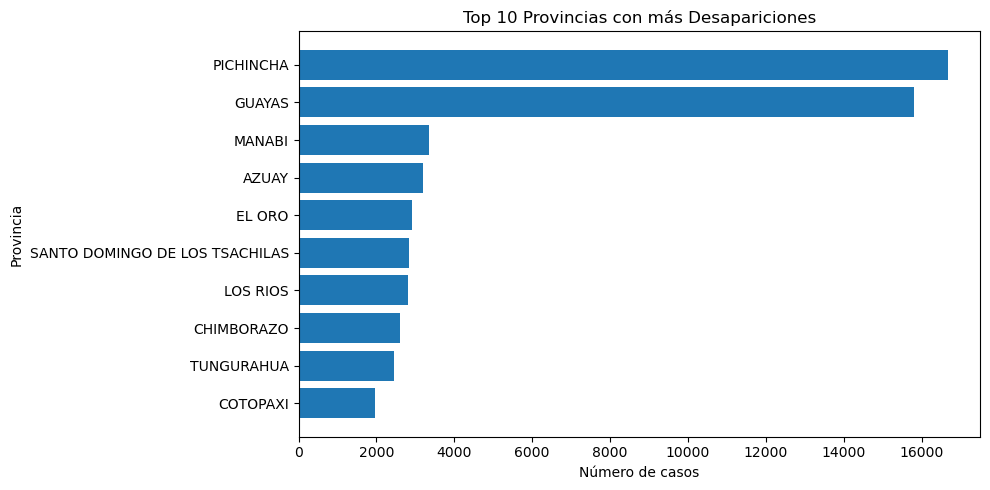

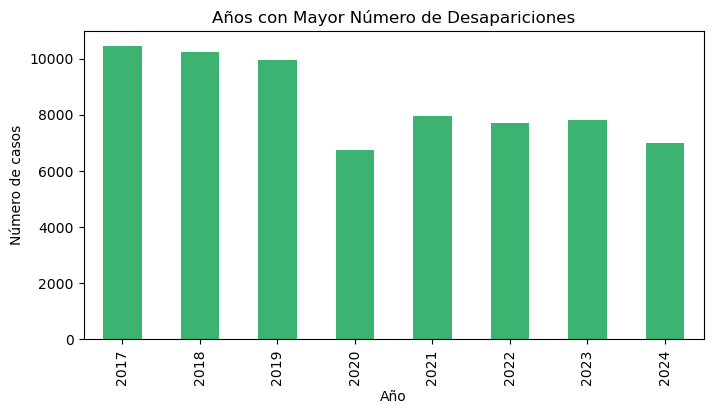

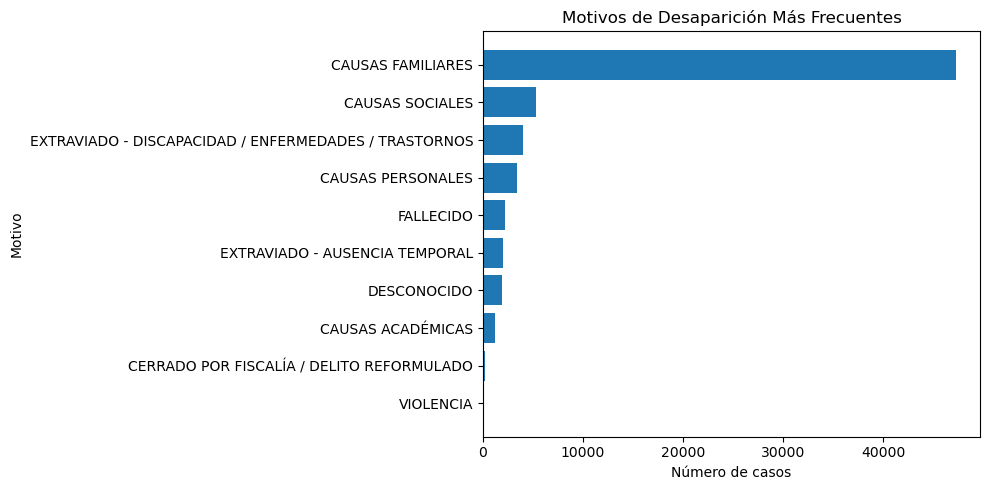

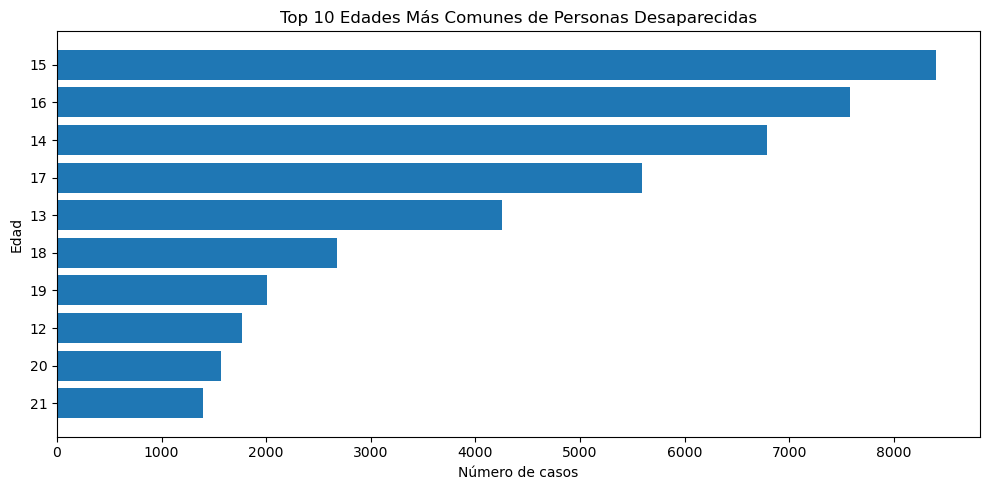

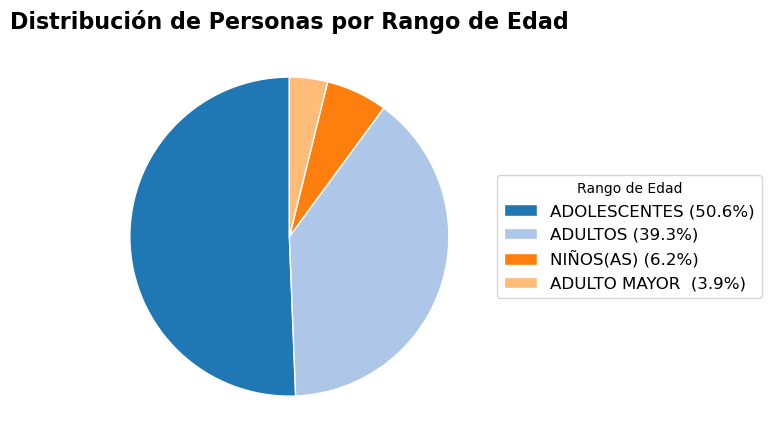

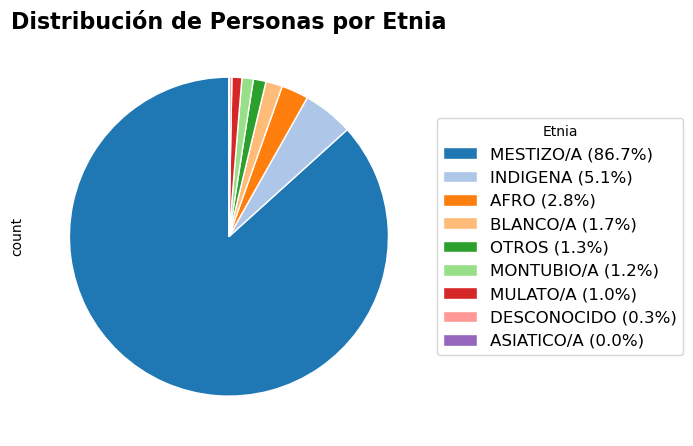

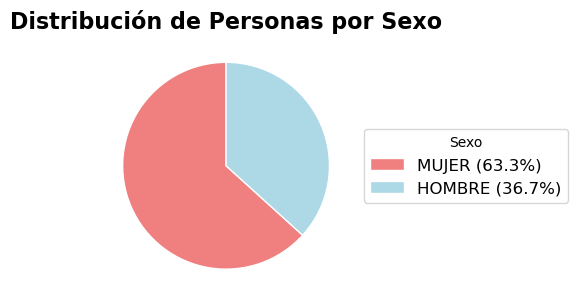

In [75]:
# Provincias
top10_provincias = top_provincias.sort_values()  # ordenar ascendente para barh
plt.figure(figsize=(10,5))
plt.barh(top10_provincias.index, top10_provincias.values)
plt.title('Top 10 Provincias con más Desapariciones')
plt.xlabel('Número de casos')
plt.ylabel('Provincia')
plt.tight_layout()
plt.savefig("Figuras/top10_provincias.png", dpi=300, bbox_inches='tight')
plt.show()

# Años
plt.figure(figsize=(8,4))
top_year.plot(kind='bar', color='mediumseagreen')
plt.title('Años con Mayor Número de Desapariciones')
plt.xlabel('Año')
plt.ylabel('Número de casos')
plt.tight_layout
plt.savefig("Figuras/top_años.png", dpi=300, bbox_inches='tight')
plt.show()

# Motivos
top10_motivos = top_motivos.sort_values()  # ordenar ascendente para barh
plt.figure(figsize=(10,5))
plt.barh(top10_motivos.index, top10_motivos.values)
plt.title('Motivos de Desaparición Más Frecuentes')
plt.xlabel('Número de casos')
plt.ylabel('Motivo')
plt.tight_layout()
plt.savefig("Figuras/top_motivos.png", dpi=300, bbox_inches='tight')
plt.show()

# Edad
top10_edades = top_edades.sort_values()  # ordenar ascendente para barh
plt.figure(figsize=(10,5))
plt.barh(top10_edades.index, top10_edades.values)
plt.title('Top 10 Edades Más Comunes de Personas Desaparecidas')
plt.xlabel('Número de casos')
plt.ylabel('Edad')
plt.tight_layout()
plt.savefig("Figuras/top_edad.png", dpi=300, bbox_inches='tight')
plt.show()

# Rango de edad
plt.figure(figsize=(7,7))
colors = plt.cm.tab20.colors  # paleta de colores

# Calcular los porcentajes para la leyenda
total = dist_rango_edad.sum()
labels = [f"{idx} ({count/total*100:.1f}%)" for idx, count in zip(dist_rango_edad.index, dist_rango_edad.values)]

dist_rango_edad.plot(
    kind='pie',
    labels=None,          # quitar etiquetas dentro del gráfico
    startangle=90,
    colors=colors,
    autopct=None,         # no mostrar porcentajes dentro
    wedgeprops={'edgecolor':'w'}  # bordes blancos
)

plt.title('Distribución de Personas por Rango de Edad', fontsize=16, fontweight='bold')
plt.ylabel('')
plt.legend(labels, title='Rango de Edad', loc='center left', bbox_to_anchor=(1, 0, 0.5, 1), fontsize=12)

plt.tight_layout()
plt.savefig("Figuras/dist_rango_edad.png", dpi=300, bbox_inches='tight')
plt.show()

# Etnia

plt.figure(figsize=(7,7))
colors = plt.cm.tab20.colors

# Calcular los porcentajes
total = dist_etnia.sum()
labels = [f"{idx} ({count/total*100:.1f}%)" for idx, count in zip(dist_etnia.index, dist_etnia.values)]

dist_etnia.plot(
    kind='pie',
    labels=None,          # quitamos etiquetas dentro del gráfico
    startangle=90,
    colors=colors,
    autopct=None,         # no mostrar porcentajes dentro
    wedgeprops={'edgecolor':'w'}  # bordes blancos
)

plt.title('Distribución de Personas por Etnia', fontsize=16, fontweight='bold')
plt.legend(labels, title='Etnia', loc='center left', bbox_to_anchor=(1, 0, 0.5, 1), fontsize=12)

plt.tight_layout()
plt.savefig("Figuras/dist_etnia.png", dpi=300, bbox_inches='tight')
plt.show()

# Sexo
plt.figure(figsize=(5,5))
colors = ['lightcoral', 'lightblue']

# Calcular los porcentajes para la leyenda
total = dist_sexo.sum()
labels = [f"{idx} ({count/total*100:.1f}%)" for idx, count in zip(dist_sexo.index, dist_sexo.values)]

dist_sexo.plot(
    kind='pie',
    labels=None,          # quitamos etiquetas dentro del gráfico
    startangle=90,
    colors=colors,
    autopct=None,         # no mostrar porcentajes dentro
    wedgeprops={'edgecolor':'w'}  # bordes blancos
)

plt.title('Distribución de Personas por Sexo', fontsize=16, fontweight='bold')
plt.ylabel('')
plt.legend(labels, title='Sexo', loc='center left', bbox_to_anchor=(1, 0, 0.5, 1), fontsize=12)

plt.tight_layout()
plt.savefig("Figuras/dist_sexo.png", dpi=300, bbox_inches='tight')
plt.show()

### Preparación para el modelo y usando datos demográficos 

In [43]:
# Librerías
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [78]:
# Selección de columnas relevantes (ajusta según tu dataset)
cols = ['sexo', 'provincia', 'nacionalidad', 'edad_aproximada', 'etnia', 'situacion_actual']
df_model = df_sql[cols].copy()

# --- Convertir variable objetivo a binaria ---
df_model['situacion_actual'] = df_model['situacion_actual'].map({
    'ENCONTRADO': 1,
    'FALLECIDO': 1,
    'DESAPARECIDO': 0
}).astype(int)

# --- Limpieza y conversión de edad ---
df_model['edad_aproximada'] = pd.to_numeric(df_model['edad_aproximada'], errors='coerce')
mediana_edad = df_model['edad_aproximada'].median()
df_model['edad_aproximada'] = df_model['edad_aproximada'].fillna(mediana_edad).astype(int)

# --- Codificación de variables categóricas ---
categorical_cols = ['sexo', 'provincia', 'nacionalidad', 'etnia']
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    label_encoders[col] = le

# --- Separar features y variable objetivo ---
X = df_model.drop('situacion_actual', axis=1)
y = df_model['situacion_actual'].values

# --- División en entrenamiento y prueba ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# --- Escalado solo de columnas numéricas ---
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled['edad_aproximada'] = scaler.fit_transform(X_train[['edad_aproximada']])
X_test_scaled['edad_aproximada'] = scaler.transform(X_test[['edad_aproximada']])

### Entrenamiento y comparación de modelos:

In [48]:
#pip install xgboost

In [79]:
# Importamos librearías:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import f1_score, roc_auc_score
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       571
           1       0.97      1.00      0.99     19808

    accuracy                           0.97     20379
   macro avg       0.49      0.50      0.49     20379
weighted avg       0.94      0.97      0.96     20379



/Users/alexisgarzon/anaconda3/envs/nb7/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/alexisgarzon/anaconda3/envs/nb7/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/alexisgarzon/anaconda3/envs/nb7/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier,


=== Random Forest ===
              precision    recall  f1-score   support

           0       0.16      0.03      0.06       571
           1       0.97      0.99      0.98     19808

    accuracy                           0.97     20379
   macro avg       0.57      0.51      0.52     20379
weighted avg       0.95      0.97      0.96     20379



/Users/alexisgarzon/anaconda3/envs/nb7/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [02:52:53] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



=== XGBoost ===
              precision    recall  f1-score   support

           0       0.22      0.01      0.02       571
           1       0.97      1.00      0.99     19808

    accuracy                           0.97     20379
   macro avg       0.59      0.50      0.50     20379
weighted avg       0.95      0.97      0.96     20379


Resultados comparativos:
                 Modelo  Accuracy  F1 Score   ROC-AUC
0  Logistic Regression  0.971981  0.985791  0.735144
2              XGBoost  0.971343  0.985460  0.768412
1        Random Forest  0.968006  0.983728  0.666866


/var/folders/c7/rzlfx3rd733_6wqmqtwkx84w0000gp/T/ipykernel_41668/3882933278.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy', y='Modelo', data=results_df, palette='viridis')


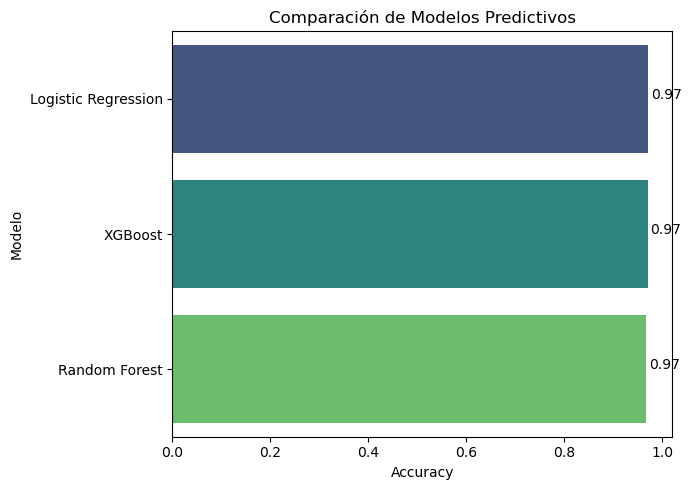

In [80]:
# --- Modelos a evaluar ---
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

results = []

# --- División de datos (ya escalados si aplica) ---
# X_train_scaled, X_test_scaled, y_train, y_test asumidos preparados previamente

for name, model in models.items():
    # Entrenamiento
    model.fit(X_train_scaled, y_train)
    
    # Predicciones
    preds = model.predict(X_test_scaled)
    probs = model.predict_proba(X_test_scaled)[:,1]  # Probabilidad de ser localizado
    
    # Métricas
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    roc_auc = roc_auc_score(y_test, probs)
    
    results.append({'Modelo': name, 'Accuracy': acc, 'F1 Score': f1, 'ROC-AUC': roc_auc})
    
    print(f"\n=== {name} ===")
    print(classification_report(y_test, preds))

# --- Comparación en DataFrame ---
results_df = pd.DataFrame(results).sort_values(by='Accuracy', ascending=False)
print("\nResultados comparativos:\n", results_df)

# --- Gráfico de comparación de Accuracy ---
plt.figure(figsize=(7,5))
sns.barplot(x='Accuracy', y='Modelo', data=results_df, palette='viridis')
for index, value in enumerate(results_df['Accuracy']):
    plt.text(value + 0.005, index, f"{value:.2f}")
plt.title('Comparación de Modelos Predictivos')
plt.tight_layout()
plt.savefig("Figuras/comparacion_modelos.png", dpi=300, bbox_inches='tight')
plt.show()

	•	Según Accuracy, Logistic Regression es ligeramente mejor.
	•	Según ROC-AUC, XGBoost tiene mejor discriminación de probabilidades.
	•	Para la aplicación en Streamlit, donde se quiere mostrar la probabilidad de ser localizado, XGBoost podría ser más confiable, porque su ROC-AUC más alto indica que las probabilidades son más calibradas.

### Selección y guardado del mejor modelo:

In [86]:
# --- Guardar el mejor modelo según ROC-AUC ---
best_model_name = results_df.sort_values(by='ROC-AUC', ascending=False).iloc[0]['Modelo']
best_model = models[best_model_name]

# Guardar con joblib
import joblib
joblib.dump(best_model, 'best_model.pkl')

# --- Guardar label encoders y scaler ---
joblib.dump(label_encoders, 'label_encoders.pkl')
joblib.dump(scaler, 'scaler.pkl')

print(f"\n✅ El mejor modelo según ROC-AUC es {best_model_name}.")
print("Archivos guardados: best_model.pkl, label_encoders.pkl, scaler.pkl")


✅ El mejor modelo según ROC-AUC es XGBoost.
Archivos guardados: best_model.pkl, label_encoders.pkl, scaler.pkl


In [56]:
#pip install streamlit